# Criterios de Partición en Árboles de Clasificación

Diego Dueñas Martín

En árboles de **regresión** usamos varianza. En **clasificación** necesitamos otras métricas porque las salidas son categorías.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('Heart Prediction Quantum Dataset.csv')
print(f"Dataset: {df.shape[0]} muestras")
print(f"\nClases: {df['HeartDisease'].value_counts().to_dict()}")

Dataset: 500 muestras

Clases: {1: 300, 0: 200}


## 1. GINI

**Fórmula**: $Gini = 1 - \sum p_i^2$

**Qué mide**: Probabilidad de clasificar mal si etiquetas aleatoriamente

- Gini = 0 → Nodo puro (todas las muestras misma clase)
- Gini = 0.5 → Máxima impureza (50-50 en binario)

In [3]:
def gini(y):
    """Calcula índice de Gini"""
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1 - np.sum(p**2)

# Ejemplo
y_ejemplo = np.array([0, 0, 0, 1, 1, 1])  # 50-50
print(f"Gini (50-50): {gini(y_ejemplo):.4f}")

y_puro = np.array([1, 1, 1, 1, 1, 1])     # 100% clase 1
print(f"Gini (puro): {gini(y_puro):.4f}")

Gini (50-50): 0.5000
Gini (puro): 0.0000


## 2. ENTROPÍA

**Fórmula**: $H = -\sum p_i \log_2(p_i)$

**Qué mide**: Cantidad de "desorden" o incertidumbre (en bits)

- H = 0 → Nodo puro (certeza total)
- H = 1 → Máxima incertidumbre (50-50 en binario)

In [4]:
def entropy(y):
    """Calcula entropía"""
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum([pi * np.log2(pi) for pi in p if pi > 0])

# Ejemplo
print(f"Entropía (50-50): {entropy(y_ejemplo):.4f} bits")
print(f"Entropía (puro): {entropy(y_puro):.4f} bits")

Entropía (50-50): 1.0000 bits
Entropía (puro): -0.0000 bits


## 3. LOG LOSS

**Fórmula**: $-\frac{1}{N}\sum [y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$

**Qué mide**: Error entre predicciones y valores reales

- Penaliza fuertemente predicciones confiadas pero equivocadas
- Se usa en regresión logística y gradient boosting

In [5]:
def log_loss(y_true, y_pred):
    """Calcula log loss"""
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Ejemplo: predicciones usando proporciones
y_true = np.array([1, 1, 1, 0, 0, 0])
y_pred = np.full(6, 0.5)  # Predigo 50% para todos
print(f"Log Loss (predicción 50%): {log_loss(y_true, y_pred):.4f}")

Log Loss (predicción 50%): 0.6931


## DIFERENCIA: Entropía vs Log Loss

| Aspecto | Entropía | Log Loss |
|---------|----------|----------|
| **Qué mide** | Incertidumbre de una distribución | Error entre predicciones y verdad |
| **Input** | Solo las etiquetas (y) | Etiquetas + predicciones (y, ŷ) |
| **Contexto** | Propiedad del conjunto | Evaluación del modelo |

**Relación**: Cuando usas proporciones empíricas como predicciones, Log Loss converge a Entropía.

---

## Partición



In [6]:
def evaluar_split(feature, threshold, y):
    """Evalúa una partición con los tres criterios"""
    left = y[feature <= threshold]
    right = y[feature > threshold]
    
    n_left, n_right = len(left), len(right)
    n_total = len(y)
    
    # GINI
    gini_weighted = (n_left/n_total) * gini(left) + (n_right/n_total) * gini(right)
    gini_gain = gini(y) - gini_weighted
    
    # ENTROPÍA
    entropy_weighted = (n_left/n_total) * entropy(left) + (n_right/n_total) * entropy(right)
    info_gain = entropy(y) - entropy_weighted
    
    # LOG LOSS
    p_left = np.mean(left) if n_left > 0 else 0
    p_right = np.mean(right) if n_right > 0 else 0
    
    ll_left = log_loss(left, np.full(n_left, p_left)) if n_left > 0 else 0
    ll_right = log_loss(right, np.full(n_right, p_right)) if n_right > 0 else 0
    ll_weighted = (n_left/n_total) * ll_left + (n_right/n_total) * ll_right
    
    return {
        'gini_gain': gini_gain,
        'info_gain': info_gain,
        'log_loss': ll_weighted,
        'n_left': n_left,
        'n_right': n_right,
        'p_left': np.mean(left) if n_left > 0 else 0,
        'p_right': np.mean(right) if n_right > 0 else 0
    }

In [7]:
def mejor_split(feature_name):
    """Encuentra el mejor umbral para una característica"""
    feature = df[feature_name].values
    y = df['HeartDisease'].values
    
    # Probar diferentes umbrales
    thresholds = np.percentile(feature, np.linspace(10, 90, 20))
    
    mejor_gini = {'threshold': None, 'gini_gain': -np.inf}
    mejor_entropy = {'threshold': None, 'info_gain': -np.inf}
    mejor_logloss = {'threshold': None, 'log_loss': np.inf}
    
    for t in thresholds:
        metrics = evaluar_split(feature, t, y)
        
        if metrics['gini_gain'] > mejor_gini['gini_gain']:
            mejor_gini = {**metrics, 'threshold': t}
        
        if metrics['info_gain'] > mejor_entropy['info_gain']:
            mejor_entropy = {**metrics, 'threshold': t}
        
        if metrics['log_loss'] < mejor_logloss['log_loss']:
            mejor_logloss = {**metrics, 'threshold': t}
    
    return mejor_gini, mejor_entropy, mejor_logloss

### Ejemplo: Partición con Age

In [8]:
gini_split, entropy_split, logloss_split = mejor_split('Age')

print("=" * 60)
print("MEJOR PARTICIÓN SEGÚN GINI")
print("=" * 60)
print(f"Umbral: Age ≤ {gini_split['threshold']:.2f}")
print(f"Ganancia Gini: {gini_split['gini_gain']:.4f}")
print(f"Izquierda: {gini_split['n_left']} muestras ({gini_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {gini_split['n_right']} muestras ({gini_split['p_right']:.1%} con enfermedad)")

print("\n" + "=" * 60)
print("MEJOR PARTICIÓN SEGÚN ENTROPÍA")
print("=" * 60)
print(f"Umbral: Age ≤ {entropy_split['threshold']:.2f}")
print(f"Information Gain: {entropy_split['info_gain']:.4f} bits")
print(f"Izquierda: {entropy_split['n_left']} muestras ({entropy_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {entropy_split['n_right']} muestras ({entropy_split['p_right']:.1%} con enfermedad)")

print("\n" + "=" * 60)
print("MEJOR PARTICIÓN SEGÚN LOG LOSS")
print("=" * 60)
print(f"Umbral: Age ≤ {logloss_split['threshold']:.2f}")
print(f"Log Loss ponderado: {logloss_split['log_loss']:.4f}")
print(f"Izquierda: {logloss_split['n_left']} muestras ({logloss_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {logloss_split['n_right']} muestras ({logloss_split['p_right']:.1%} con enfermedad)")

MEJOR PARTICIÓN SEGÚN GINI
Umbral: Age ≤ 64.00
Ganancia Gini: 0.0653
Izquierda: 355 muestras (48.5% con enfermedad)
Derecha: 145 muestras (88.3% con enfermedad)

MEJOR PARTICIÓN SEGÚN ENTROPÍA
Umbral: Age ≤ 64.00
Information Gain: 0.1102 bits
Izquierda: 355 muestras (48.5% con enfermedad)
Derecha: 145 muestras (88.3% con enfermedad)

MEJOR PARTICIÓN SEGÚN LOG LOSS
Umbral: Age ≤ 64.00
Log Loss ponderado: 0.5966
Izquierda: 355 muestras (48.5% con enfermedad)
Derecha: 145 muestras (88.3% con enfermedad)


### Ejemplo: Partición con QuantumPatternFeature

In [9]:
gini_split, entropy_split, logloss_split = mejor_split('QuantumPatternFeature')

print("=" * 60)
print("MEJOR PARTICIÓN SEGÚN GINI")
print("=" * 60)
print(f"Umbral: QuantumPatternFeature ≤ {gini_split['threshold']:.2f}")
print(f"Ganancia Gini: {gini_split['gini_gain']:.4f}")
print(f"Izquierda: {gini_split['n_left']} muestras ({gini_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {gini_split['n_right']} muestras ({gini_split['p_right']:.1%} con enfermedad)")

print("\n" + "=" * 60)
print("MEJOR PARTICIÓN SEGÚN ENTROPÍA")
print("=" * 60)
print(f"Umbral: QuantumPatternFeature ≤ {entropy_split['threshold']:.2f}")
print(f"Information Gain: {entropy_split['info_gain']:.4f} bits")
print(f"Izquierda: {entropy_split['n_left']} muestras ({entropy_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {entropy_split['n_right']} muestras ({entropy_split['p_right']:.1%} con enfermedad)")

print("\n" + "=" * 60)
print("MEJOR PARTICIÓN SEGÚN LOG LOSS")
print("=" * 60)
print(f"Umbral: QuantumPatternFeature ≤ {logloss_split['threshold']:.2f}")
print(f"Log Loss ponderado: {logloss_split['log_loss']:.4f}")
print(f"Izquierda: {logloss_split['n_left']} muestras ({logloss_split['p_left']:.1%} con enfermedad)")
print(f"Derecha: {logloss_split['n_right']} muestras ({logloss_split['p_right']:.1%} con enfermedad)")

MEJOR PARTICIÓN SEGÚN GINI
Umbral: QuantumPatternFeature ≤ 8.50
Ganancia Gini: 0.3505
Izquierda: 282 muestras (96.8% con enfermedad)
Derecha: 218 muestras (12.4% con enfermedad)

MEJOR PARTICIÓN SEGÚN ENTROPÍA
Umbral: QuantumPatternFeature ≤ 8.37
Information Gain: 0.6210 bits
Izquierda: 261 muestras (99.2% con enfermedad)
Derecha: 239 muestras (17.2% con enfermedad)

MEJOR PARTICIÓN SEGÚN LOG LOSS
Umbral: QuantumPatternFeature ≤ 8.37
Log Loss ponderado: 0.2426
Izquierda: 261 muestras (99.2% con enfermedad)
Derecha: 239 muestras (17.2% con enfermedad)


### Comparar todas las características

In [10]:
caracteristicas = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate', 'QuantumPatternFeature']

resultados = []
for feat in caracteristicas:
    gini_s, entropy_s, logloss_s = mejor_split(feat)
    resultados.append({
        'Característica': feat,
        'Gini Gain': gini_s['gini_gain'],
        'Info Gain': entropy_s['info_gain'],
        'Log Loss': logloss_s['log_loss']
    })

comparacion = pd.DataFrame(resultados)
comparacion = comparacion.sort_values('Info Gain', ascending=False)
print("\n" + "=" * 60)
print("RANKING DE CARACTERÍSTICAS")
print("=" * 60)
print(comparacion.to_string(index=False))
print("\nMejor característica: QuantumPatternFeature (mayor Information Gain)")


RANKING DE CARACTERÍSTICAS
       Característica  Gini Gain  Info Gain  Log Loss
QuantumPatternFeature   0.350525   0.621021  0.242553
          Cholesterol   0.072891   0.110633  0.596327
                  Age   0.065313   0.110243  0.596597
        BloodPressure   0.011322   0.017117  0.661147
            HeartRate   0.007607   0.012211  0.664548

Mejor característica: QuantumPatternFeature (mayor Information Gain)


### Visualización

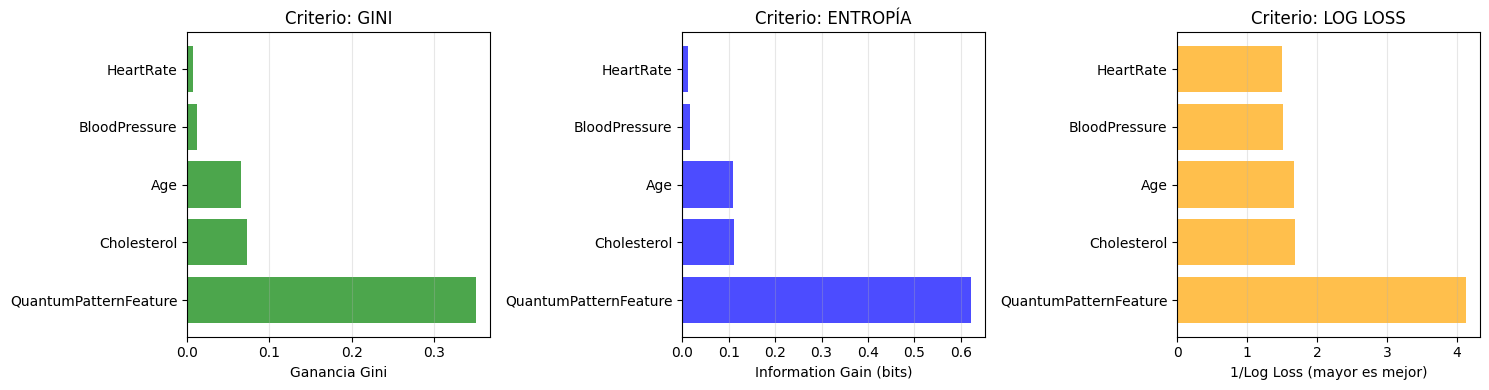

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gini
axes[0].barh(comparacion['Característica'], comparacion['Gini Gain'], color='green', alpha=0.7)
axes[0].set_xlabel('Ganancia Gini')
axes[0].set_title('Criterio: GINI')
axes[0].grid(axis='x', alpha=0.3)

# Entropía
axes[1].barh(comparacion['Característica'], comparacion['Info Gain'], color='blue', alpha=0.7)
axes[1].set_xlabel('Information Gain (bits)')
axes[1].set_title('Criterio: ENTROPÍA')
axes[1].grid(axis='x', alpha=0.3)

# Log Loss (invertir para que menor sea mejor visualmente)
axes[2].barh(comparacion['Característica'], 1/comparacion['Log Loss'], color='orange', alpha=0.7)
axes[2].set_xlabel('1/Log Loss (mayor es mejor)')
axes[2].set_title('Criterio: LOG LOSS')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusiones

1. **GINI**: Más rápido de calcular (no usa logaritmos)
2. **ENTROPÍA**: Mejor interpretación teórica (bits de información)
3. **LOG LOSS**: Alineado con modelos probabilísticos

En la práctica, los tres producen árboles similares.

**Para este dataset**: QuantumPatternFeature es la característica más discriminativa.